In [1]:
import numpy as np
import vrplib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [ ]:
def solve(path: str, rounding: bool=True) -> list[list]:
    data = vrplib.read_instance(path)
    n = data['dimension']
    Q = data['capacity']
    distances = data['edge_weight']
    demands = data['demand']

    if rounding:
        for ii in range(n):
            for jj in range(n):
                distances[ii][jj] = round(distances[ii][jj])

    return []

In [14]:
def run_solution(path, rounding=True):
    path = path.split(".")[0]

    data = vrplib.read_instance(path + '.vrp')
    sol = vrplib.read_solution(path + '.sol')

    n = data['dimension']
    Q = data['capacity']
    demands = data['demand']
    edges = data['edge_weight']

    k = len(sol['routes'])

    if rounding:
        for ii in range(n):
            for jj in range(n):
                edges[ii][jj] = round(edges[ii][jj])

    res = solve(path + '.vrp')

    if not isinstance(res, list):
        raise Exception("The answer is not a list")

    if len(res) > k:
        raise Exception("Too many vehicles are used")
    
    visited = set([0])
    total = 0
    for i in range(len(res)):
        cap = 0
        route = res[i]
        
        if not isinstance(route, list):
                raise Exception(f"res[{i}] is not a list")
        
        route = [0] + route + [0]
        for j in range(len(route)):
            if route[j] > 0 and route[j] in visited:
                raise Exception(f"Client {route[j]} visited twice")
            cap += demands[route[j]]
            visited.add(route[j])
        if cap > Q:
            raise Exception("Route capacity is exceeded")
        total += np.sum([edges[route[j]][[route[j + 1]]] for j in range(len(route) - 1)])
    
    if len(visited) != n:
        raise Exception("Some clients are not visited")
    
    
    return {
        "routes": res,
        "cost": total,
        "true_routes": sol['routes'],
        "true_cost" : sol['cost']
    }

In [15]:
def plot_solution(path: str, res: dict):
    """
    Plot the routes of the passed-in solution.
    """
    routes, cost = res['routes'], res['cost']
    true_routes, true_cost = res['true_routes'], res['true_cost']

    data = vrplib.read_instance(path)



    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    cmap_1 = cm.rainbow(np.linspace(0, 1, len(routes)))
    cmap_2 = cm.rainbow(np.linspace(0, 1, len(true_routes)))

    for idx, route in enumerate(routes):
        ax[0].plot(
            [data["node_coord"][loc][0] for loc in [0] + route + [0]],
            [data["node_coord"][loc][1] for loc in [0] + route + [0]],
            color=cmap_1[idx],
            marker=".",
        )
    for idx, route in enumerate(true_routes):
        ax[1].plot(
            [data["node_coord"][loc][0] for loc in [0] + route + [0]],
            [data["node_coord"][loc][1] for loc in [0] + route + [0]],
            color=cmap_2[idx],
            marker=".",
        )

    # Plot the depot
    kwargs = dict(label="Depot", zorder=3, marker="*", s=750)

    ax[0].set_title(f"Solution\n Total distance: {cost}")
    ax[1].set_title(f"Benchmark solution\n Total distance: {true_cost}")

    for i in range(2):
        ax[i].set_xlabel("X-coordinate")
        ax[i].set_ylabel("Y-coordinate")
        ax[i].legend(frameon=False, ncol=3)
        ax[i].scatter(*data["node_coord"][0], c="tab:red", **kwargs)

C:\Users\polly\AppData\Local\Temp\ipykernel_17996\557973452.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(frameon=False, ncol=3)


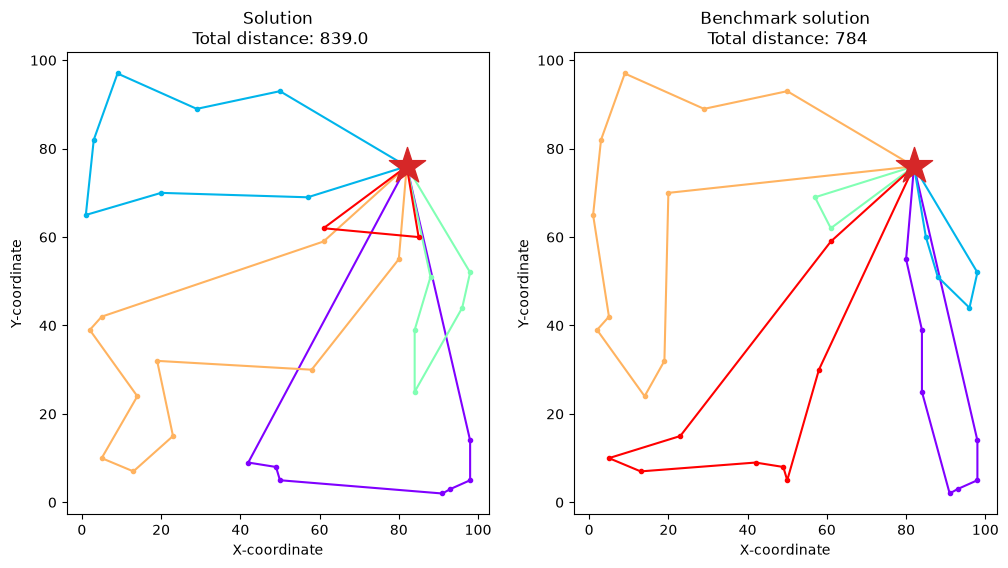

In [ ]:
path = None # path to instance
res = run_solution(path)
plot_solution(path, res)